# Load and scale ethe cifar10 data

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape)
print(y_train.shape) #my labels to to the corresponding image
print(X_train[0])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7256s 43us/step
(50000, 32, 32, 3)
(50000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


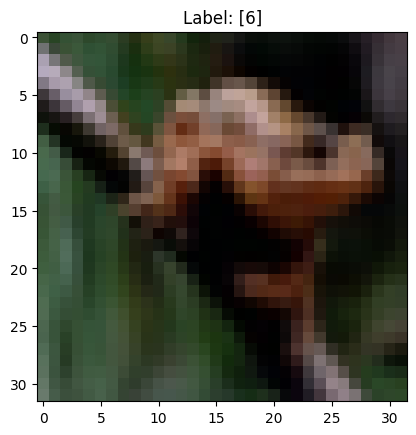

In [9]:
import matplotlib.pyplot as plt
plt.imshow(X_train[5000])
plt.title(f"Label: {y_train[5000]}")
plt.show()

In [10]:
X_train_scaled = X_train/ 255.0
X_test_scaled = X_test/ 255.0

In [ ]:
y_train_flat = y_train.flatten() 
y_test_flat = y_test.flatten()
print(y_train_flat.shape)

(50000,)


# CNN model

In [13]:
from tensorflow.keras import layers, Sequential

cifar_model = Sequential([
    layers.Conv2D(filters = 32, 
                  kernel_size=(3,3), 
                  activation='relu', 
                  input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2], X_train_scaled.shape[3])),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(filters=64,
                  kernel_size=(3,3),
                  activation='relu'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(units=64, activation ='relu'),
    layers.Dense(units=32, activation='relu'),
    layers.Dense(units=10, activation='softmax')
])


c:\Users\Edward\Desktop\python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cifar_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cifar_history = cifar_model.fit(
    X_train_scaled, y_train_flat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_scaled, y_test_flat)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4272 - loss: 1.5653 - val_accuracy: 0.5292 - val_loss: 1.3175
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5817 - loss: 1.1871 - val_accuracy: 0.6072 - val_loss: 1.1242
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6281 - loss: 1.0583 - val_accuracy: 0.6464 - val_loss: 1.0268
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6605 - loss: 0.9732 - val_accuracy: 0.6523 - val_loss: 1.0034
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6854 - loss: 0.9085 - val_accuracy: 0.6560 - val_loss: 0.9907
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7041 - loss: 0.8554 - val_accuracy: 0.6632 - val_loss: 0.9560
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7179 - loss: 0.8100 - val_accuracy: 0.6519 - val_loss: 1.0100
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7318 - loss: 0.7697 - val_accur

# Comparing with early stopping and dropout

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

cifar_model_v2 = Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                  input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2], X_train_scaled.shape[3])),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(units=32, activation='relu'),
    layers.Dense(units=10, activation='softmax')
])

cifar_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cifar_history_v2 = cifar_model_v2.fit(
    X_train_scaled, y_train_flat,
    epochs=30,  
    batch_size=64,
    validation_data=(X_test_scaled, y_test_flat),
    callbacks=[early_stop]
)

#improvements in results is very minimal, which suggest the dense layer
#isn't struggling to combine features. its more liklely struggling to 
#extract rih enough features in the first, so imma add one more ccn layer

c:\Users\Edward\Desktop\python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2881 - loss: 1.8903 - val_accuracy: 0.4626 - val_loss: 1.5211
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4110 - loss: 1.5886 - val_accuracy: 0.4850 - val_loss: 1.4404
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4590 - loss: 1.4707 - val_accuracy: 0.5510 - val_loss: 1.2735
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4942 - loss: 1.3932 - val_accuracy: 0.5832 - val_loss: 1.2447
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5160 - loss: 1.3385 - val_accuracy: 0.5802 - val_loss: 1.1835
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5343 - loss: 1.2891 - val_accuracy: 0.6197 - val_loss: 1.1140
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5488 - loss: 1.2538 - val_accuracy: 0.6186 - val_loss: 1.1211
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5624 - loss: 1.2202 - val_acc

# adding another cnn layer

In [ ]:
cifar_model_v3 = Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                  input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2], X_train_scaled.shape[3])),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(units=10, activation='softmax')
])

cifar_model_v3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cifar_history_v3 = cifar_model_v3.fit(
    X_train_scaled, y_train_flat,
    epochs=30,
    batch_size=64,
    validation_data=(X_test_scaled, y_test_flat),
    callbacks=[early_stop]
)

print(f"Best val_loss: {min(cifar_history_v3.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(cifar_history_v3.history['val_accuracy']):.4f}")

#Adding the third convolutional layer genuinely pushed performance meaningfully higher
# — confirming that feature extraction depth, not Dense-layer capacity, was the actual bottleneck

#when a CNN's ceiling feels capped, testing additional convolutional layers before adding Dense capacity 
#is often the more productive first move, since convolutional layers are what build increasingly complex 
# visual understanding, while Dense layers just combine whatever's already been extracted.

# CIFAR-10: color images (32,32,3) vs MNIST's grayscale (28,28,1) — same
# Conv2D/MaxPool2D/Flatten/Dense mechanism throughout, only input_shape differs

# v1: 2 conv layers, no regularization — val_accuracy 0.694, real train/val gap
# v2: same 2 conv layers + Dropout(0.25 conv, 0.5 dense) + EarlyStopping —
#     val_accuracy ~0.66, but train/val gap genuinely closed (dropout working
#     as intended — traded some peak accuracy for a more honest, stable result)
# v3: ADDED a 3rd Conv2D layer (128 filters) — val_accuracy 0.736, clear
#     improvement. Confirms feature-extraction DEPTH, not Dense-layer width,
#     was the real bottleneck — tested as a specific hypothesis, not a guess

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.3226 - loss: 1.8199 - val_accuracy: 0.4406 - val_loss: 1.5475
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4557 - loss: 1.5097 - val_accuracy: 0.5421 - val_loss: 1.3133
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5088 - loss: 1.3762 - val_accuracy: 0.5714 - val_loss: 1.1917
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5357 - loss: 1.3032 - val_accuracy: 0.6050 - val_loss: 1.1422
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5595 - loss: 1.2455 - val_accuracy: 0.6251 - val_loss: 1.0638
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5810 - loss: 1.1968 - val_accuracy: 0.6389 - val_loss: 1.0495
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.5919 - loss: 1.1595 - val_accuracy: 0.6540 - val_loss: 0.9832
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6125 - loss: 1.1169 - 

# test our new cnn model v3 with a random picture 

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('test_dog.jpg', target_size=(32, 32)) # resizes to match training data (32x32)
img_array = image.img_to_array(img) # converts Keras's image object into a real NumPy array, shape (32,32,3)
img_array = img_array / 255.0 # same 0-255 -> 0-1 scaling as training data
img_array = np.expand_dims(img_array, axis=0) 
# adds the missing BATCH dimension: (32,32,3) -> (1,32,32,3) —
# .predict() always expects a batch, even a batch of 1

prediction = cifar_model_v3.predict(img_array)
# runs the image through every trained layer, returns (1,10) —
# 10 probabilities, one per class

predicted_class_index = np.argmax(prediction)# finds the POSITION of the highest probability, not the value itself


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print(prediction)  # the full array of 10 probabilities
print(f"Predicted class: {class_names[predicted_class_index]}")

#output is wrong HAHA should be a dog not a frog 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[0.0183593  0.02099953 0.12711494 0.07656973 0.05588219 0.05173647
  0.48224774 0.02631988 0.00632832 0.13444184]]
Predicted class: frog


# look at the scaled test image

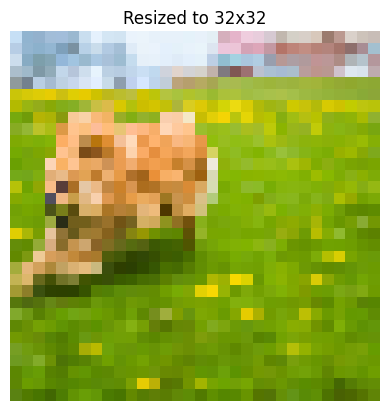

In [ ]:
plt.imshow(img)
plt.title("Resized to 32x32")
plt.axis('off')
plt.show()